LAB 6

Arancibia Estrada Alvaro David

Espinoza Cava Chelsea Melany


1. Descripción del Conjunto de Datos (Dataset)
El conjunto de datos utilizado en este proyecto proviene del desafío Bike Sharing Demand. El objetivo principal es analizar y predecir los patrones de uso del sistema público de alquiler de bicicletas basado en variables ambientales y temporales.

    1.1. Variables del Sistema
El dataset original registra la demanda de alquileres por hora, desglosada en:

- Casual: Número de alquileres realizados por usuarios no registrados.

- Registered: Número de alquileres realizados por usuarios suscritos al sistema.

- Count: El número total de alquileres (suma de los dos anteriores).

    1.2. Factores de Influencia (Características)
Para realizar las predicciones, el modelo utiliza diversas variables que afectan el comportamiento de los usuarios:

- Temporales: Fecha y hora, indicando si el día es festivo (holiday) o laboral (workingday).

- Climáticas: Temperatura real (temp), sensación térmica (atemp), humedad relativa (humidity) y velocidad del viento (windspeed).

- Meteorológicas: Categorización del clima (weather), que varía desde cielos despejados hasta condiciones de tormenta o nieve.

    1.3. Transformación del Problema
A diferencia del enfoque tradicional de regresión (predecir el número exacto de alquileres), en este cuaderno hemos transformado el problema en uno de Clasificación Multiclase.

Para ello, se han definido tres categorías de demanda basadas en los percentiles de la variable count:

- Demanda Baja (0): Horas con poca afluencia de usuarios.

- Demanda Media (1): Niveles de alquiler promedio.

- Demanda Alta (2): Horas pico de máxima utilización del sistema.

Esta transformación permite que el modelo de Red Neuronal funcione como un sistema de alerta logística, clasificando el estado de la red de bicicletas para optimizar la distribución de unidades en la ciudad.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import os

df = pd.read_csv('train.csv')
print(df.head())

              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [29]:
print('Estadísticas de count (variable objetivo original):')
print(df['count'].describe())
print(f'\nMáximo : {df["count"].max()}')
print(f'Mínimo : {df["count"].min()}')
print(f'Mediana: {df["count"].median()}')

Estadísticas de count (variable objetivo original):
count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64

Máximo : 977
Mínimo : 1
Mediana: 145.0


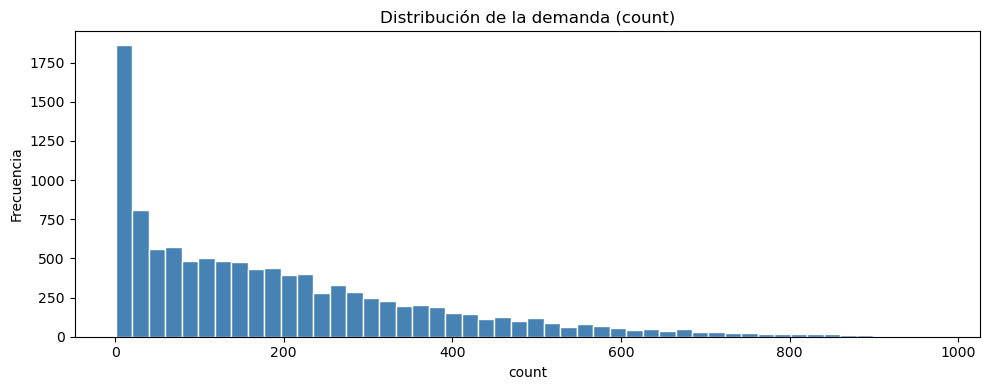

In [30]:
# Distribución del count original
plt.figure(figsize=(10, 4))
plt.hist(df['count'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribución de la demanda (count)')
plt.xlabel('count')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [31]:
# ── Calcular umbrales ──────────────────────────────────────────
p33 = df['count'].quantile(0.33)
p66 = df['count'].quantile(0.66)

print(f'Valor máximo de count : {df["count"].max()}')
print(f'Corte Baja  → Media   : {p33}  (percentil 33)')
print()
print('Rangos resultantes:')
print(f'  Clase 0 (Baja) : 1  – {int(p33)}')
print(f'  Clase 1 (Media): {int(p33)+1} – {int(p66)}')
print(f'  Clase 2 (Alta) : {int(p66)+1} – {df["count"].max()}')

Valor máximo de count : 977
Corte Baja  → Media   : 72.0  (percentil 33)

Rangos resultantes:
  Clase 0 (Baja) : 1  – 72
  Clase 1 (Media): 73 – 224
  Clase 2 (Alta) : 225 – 977


In [32]:
# ── Crear columna target ───────────────────────────────────────
def asignar_clase(count):
    """Convierte un valor continuo de demanda en clase 0/1/2."""
    if count <= p33:
        return 0  # Baja demanda
    elif count <= p66:
        return 1  # Media demanda
    else:
        return 2  # Alta demanda

df['demand_class'] = df['count'].apply(asignar_clase)

# Verificar distribución
conteo = df['demand_class'].value_counts().sort_index()
etiquetas = ['Baja (0)', 'Media (1)', 'Alta (2)']
print('Distribución de clases:')
for i, (n, et) in enumerate(zip(conteo, etiquetas)):
    pct = n / len(df) * 100
    print(f'  {et}: {n} muestras ({pct:.1f}%)')

Distribución de clases:
  Baja (0): 3601 muestras (33.1%)
  Media (1): 3597 muestras (33.0%)
  Alta (2): 3688 muestras (33.9%)


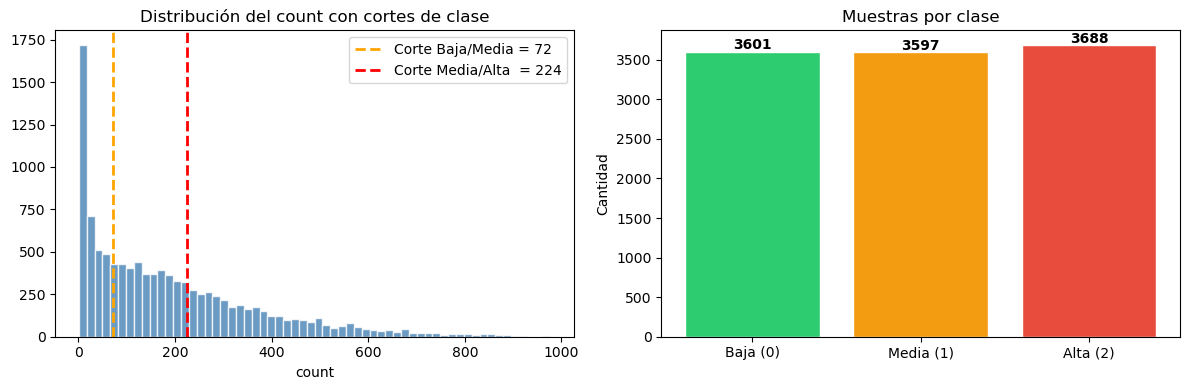

In [33]:
# Visualizar distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con fronteras de clase
axes[0].hist(df['count'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(p33, color='orange', linestyle='--', linewidth=2, label=f'Corte Baja/Media = {int(p33)}')
axes[0].axvline(p66, color='red',    linestyle='--', linewidth=2, label=f'Corte Media/Alta  = {int(p66)}')
axes[0].set_title('Distribución del count con cortes de clase')
axes[0].set_xlabel('count')
axes[0].legend()

# Barplot de clases
colores = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(etiquetas, conteo.values, color=colores, edgecolor='white')
axes[1].set_title('Muestras por clase')
axes[1].set_ylabel('Cantidad')
for i, v in enumerate(conteo.values):
    axes[1].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [34]:
# ── Extraer features temporales ────────────────────────────────
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour']     = df['datetime'].dt.hour
df['month']    = df['datetime'].dt.month
df['dayofweek']= df['datetime'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['year']     = df['datetime'].dt.year

# ── Seleccionar features y target ─────────────────────────────
# Eliminamos: datetime (ya procesado), count/casual/registered (data leakage)
FEATURES = ['season', 'holiday', 'workingday', 'weather',
            'temp', 'atemp', 'humidity', 'windspeed',
            'hour', 'month', 'dayofweek', 'year']

TARGET = 'demand_class'

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.int64)

print(f'Features shape : {X.shape}')  # (10886, 12)
print(f'Target shape   : {y.shape}')  # (10886,)
print(f'Clases únicas  : {np.unique(y)}')

Features shape : (10886, 12)
Target shape   : (10886,)
Clases únicas  : [0 1 2]


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [36]:
#Split y normalizacion

# ── Train / Validation / Test split ───────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp
)

print(f'Train : {X_train.shape[0]} muestras')
print(f'Val   : {X_val.shape[0]}   muestras')
print(f'Test  : {X_test.shape[0]}  muestras')

# ── Normalización (fit SOLO en train) ─────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

Train : 6966 muestras
Val   : 1742   muestras
Test  : 2178  muestras


In [37]:
class BikeDataset(Dataset):
    """Dataset tabular para PyTorch."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)  # ← long para CrossEntropyLoss

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_loader = DataLoader(BikeDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(BikeDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
test_loader  = DataLoader(BikeDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f'Batches en train: {len(train_loader)}')

Batches en train: 109


In [38]:
class BikeClassifier(nn.Module):
    # Cambiamos los nombres para que coincidan con la llamada
    def __init__(self, input_dim, hidden_dims, n_classes, dropout=0.3):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout) # Ahora 'dropout' sí está definido
            ]
            prev_dim = h

        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [39]:
N_FEATURES = X_train.shape[1]  # 12
N_CLASSES  = 3

model = BikeClassifier(
    input_dim   = N_FEATURES,
    hidden_dims = [128, 64, 32],
    n_classes   = N_CLASSES,
    dropout     = 0.3
)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nParámetros totales: {total_params:,}')

BikeClassifier(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)

Parámetros totales: 12,547


In [40]:
criterion = nn.CrossEntropyLoss()          # Multiclase: softmax incluido

optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)

# Reduce LR si la val_loss no mejora en 5 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

In [41]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        logits = model(X_batch)              # (batch, 3) — logits crudos
        loss   = criterion(logits, y_batch)  # CrossEntropy
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


@torch.no_grad()
def evaluate_loader(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    for X_batch, y_batch in loader:
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n


# ── Entrenamiento principal ────────────────────────────────────
EPOCHS = 200
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss  = float('inf')
best_model_wts = None

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate_loader(model, val_loader,   criterion)

    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    # Guardar el mejor modelo
    if vl_loss < best_val_loss:
        best_val_loss  = vl_loss
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.3f}  |  '
              f'Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.3f}')

# Restaurar mejor modelo
model.load_state_dict(best_model_wts)
print(f'\nMejor val_loss: {best_val_loss:.4f}')

Epoch  10/200  Train Loss: 0.5996  Acc: 0.728  |  Val   Loss: 0.5055  Acc: 0.767
Epoch  20/200  Train Loss: 0.5722  Acc: 0.747  |  Val   Loss: 0.4504  Acc: 0.801
Epoch  30/200  Train Loss: 0.5336  Acc: 0.759  |  Val   Loss: 0.4142  Acc: 0.815
Epoch  40/200  Train Loss: 0.5192  Acc: 0.770  |  Val   Loss: 0.4010  Acc: 0.820
Epoch  50/200  Train Loss: 0.5131  Acc: 0.773  |  Val   Loss: 0.3897  Acc: 0.840
Epoch  60/200  Train Loss: 0.4892  Acc: 0.789  |  Val   Loss: 0.3682  Acc: 0.853
Epoch  70/200  Train Loss: 0.4825  Acc: 0.789  |  Val   Loss: 0.3608  Acc: 0.862
Epoch  80/200  Train Loss: 0.4735  Acc: 0.796  |  Val   Loss: 0.3541  Acc: 0.865
Epoch  90/200  Train Loss: 0.4623  Acc: 0.807  |  Val   Loss: 0.3438  Acc: 0.863
Epoch 100/200  Train Loss: 0.4605  Acc: 0.799  |  Val   Loss: 0.3506  Acc: 0.873
Epoch 110/200  Train Loss: 0.4490  Acc: 0.804  |  Val   Loss: 0.3443  Acc: 0.873
Epoch 120/200  Train Loss: 0.4696  Acc: 0.794  |  Val   Loss: 0.3432  Acc: 0.869
Epoch 130/200  Train Loss: 0

**GENERAMOS PREDICCIONES**

In [42]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Ponemos el modelo en modo evaluación
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        preds = torch.argmax(logits, dim=1) # Obtenemos la clase con mayor probabilidad
        
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

### *Exactitud (Accuracy)*

En este proyecto, como clasificamos la demanda en tres niveles (Baja, Media y Alta), el Accuracy nos indica la proporción total de predicciones que el modelo hizo correctamente sobre el total de registros analizados.

Es decir, suma los casos donde el modelo dijo "Baja" y era "Baja", donde dijo "Media" y era "Media", y donde dijo "Alta" y era "Alta", dividiendo ese resultado entre todas las muestras del set de datos.

En términos del dataset:

De todas las horas del día que el modelo intentó predecir, ¿en qué porcentaje le atinó a la categoría de demanda real?

$$Accuracy = \frac{Total\ de\ Aciertos\ (Baja + Media + Alta)}{Total\ de\ Muestras}$$

In [43]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# 1. Ponemos el modelo en modo evaluación (apaga Dropout y BatchNorm)
model.eval()

y_reales = []
y_predichas = []

# 2. Obtenemos las predicciones del set de prueba sin calcular gradientes
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch)
        # torch.argmax nos da la clase (0, 1 o 2) con el valor más alto
        preds = torch.argmax(logits, dim=1)
        
        y_reales.extend(y_batch.numpy())
        y_predichas.extend(preds.numpy())

# 3. Calculamos la métrica usando Scikit-Learn como recomendó el ingeniero
accuracy_final = accuracy_score(y_reales, y_predichas)

print(f"Accuracy en el set de Prueba: {accuracy_final:.4f}")
print(f"Porcentaje de éxito: {accuracy_final * 100:.2f}%")

Accuracy en el set de Prueba: 0.8797
Porcentaje de éxito: 87.97%


### La Matriz de Confusión

Una matriz de confusión nos va a indicar exactamente cuales son los puntos fuertes y débiles de nuestro clasificador. Para cada clase, vamos a calcular cuantos elementos han sido bien clasificados por nuestro modelo y cuántos han sido confundidos con otras clases (esta matriz nos será muy útil en clasificación en varias clases también).

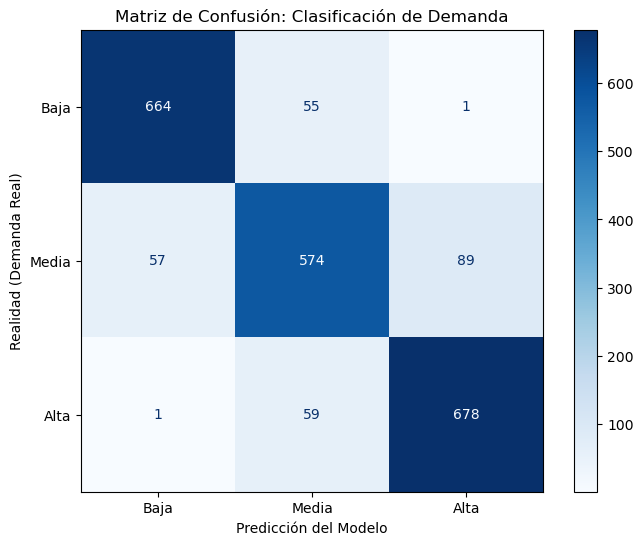

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calculamos la matriz usando sklearn
cm = confusion_matrix(y_true, y_pred)

# 2. Definimos las etiquetas de tus clases
etiquetas = ['Baja', 'Media', 'Alta']

# 3. Creamos la visualización
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)

# Graficamos con un mapa de colores (cmap) para resaltar los aciertos
disp.plot(cmap='Blues', ax=ax)

plt.title('Matriz de Confusión: Clasificación de Demanda')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Demanda Real)')
plt.show()

Verdaderos Positivos ($TP_{Alta}$): Es el número en el cuadro de la esquina inferior derecha (Fila: Alta / Col: Alta). Son las veces que el modelo acertó que habría mucha gente alquilando bicicletas.

Falsos Positivos ($FP_{Alta}$): Son los números en la columna de "Alta" que no están en la diagonal. El modelo predijo que la demanda sería mucha, pero en realidad fue "Baja" o "Media". (¡Esto causaría que sobren bicicletas en la calle!).

Falsos Negativos ($FN_{Alta}$): Son los números en la fila de "Alta" que no están en la diagonal. Realmente hubo mucha demanda, pero el modelo predijo que sería "Baja" o "Media". (¡Esto causaría que falten bicicletas!).

Verdaderos Negativos ($TN_{Alta}$): Son todos los aciertos y errores de las clases "Baja" y "Media" sumados. Es todo lo que el modelo supo que no era demanda Alta.

### *Precision* y *Recall*

Para entenderlo, fijémonos en la Demanda Alta (Clase 2):

Precisión (Precision): Responde a: "De todas las veces que el modelo predijo Demanda Alta, ¿en cuántas realmente hubo mucha demanda?".

Si es baja: El modelo es "alarmista". Predice mucha demanda cuando no la hay, lo que haría que mandes bicicletas a estaciones que se quedarán llenas sin usarse.

Sensibilidad (Recall): Responde a: "De todas las veces que realmente hubo Demanda Alta, ¿cuántas logró detectar el modelo?".

Si es baja: El modelo es "despistado". No ve venir los picos de demanda y la gente se quedaría sin bicicletas en las estaciones.

Usaremos classification_report de Scikit-Learn

In [45]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Usamos las variables y_reales y y_predichas que calculamos anteriormente
# average=None nos devuelve una lista con la métrica para [Baja, Media, Alta]
pre = precision_score(y_reales, y_predichas, average=None)
rec = recall_score(y_reales, y_predichas, average=None)

print(f"{'Clase':<12} | {'Precision':<10} | {'Recall':<10}")
print("-" * 50)
categorias = ['Baja (0)', 'Media (1)', 'Alta (2)']
for i, cat in enumerate(categorias):
    print(f"{cat:<12} | {pre[i]:.4f}     | {rec[i]:.4f}")

Clase        | Precision  | Recall    
--------------------------------------------------
Baja (0)     | 0.9197     | 0.9222
Media (1)    | 0.8343     | 0.7972
Alta (2)     | 0.8828     | 0.9187


### F1-Score

A veces, un modelo puede tener una precision muy alta pero un recall muy bajo (o viceversa). El F1-Score es una media especial (armónica) que penaliza los valores extremos.

¿Por qué es útil para las bicicletas?Si tu modelo predice muy bien la "Demanda Alta" (alta precisión) pero se le escapan muchos casos reales (bajo recall), el F1-Score bajará. Solo será alto si el modelo es bueno tanto en no dar falsas alarmas como en no perderse ningún picos de demanda.$$F_1 = 2 \times \frac{precision \times recall}{precision + recall}$$Punto clave: Como señala tu ingeniero, esta métrica favorece a los modelos que tienen valores similares de precision y recall.

In [46]:
from sklearn.metrics import f1_score

# 1. Calculamos el F1-Score para cada una de tus 3 clases
f1_por_clase = f1_score(y_reales, y_predichas, average=None)

# 2. Calculamos el promedio general (Macro F1)
f1_general = f1_score(y_reales, y_predichas, average='macro')

print("F1-SCORE POR NIVEL DE DEMANDA:")
print(f"- Baja (0):  {f1_por_clase[0]:.4f}")
print(f"- Media (1): {f1_por_clase[1]:.4f}")
print(f"- Alta (2):  {f1_por_clase[2]:.4f}")
print(f"\nF1-Score Global del Modelo: {f1_general:.4f}")

F1-SCORE POR NIVEL DE DEMANDA:
- Baja (0):  0.9209
- Media (1): 0.8153
- Alta (2):  0.9004

F1-Score Global del Modelo: 0.8789


### La curva ROC

La curva ROC (Receiver Operating Characteristic) permite visualizar el comportamiento del modelo para varios umbrales (thresholds). En ella representamos el ratio de verdaderos positivos (TPR) contra el ratio de falsos positivos (FPR).

TPR (Sensibilidad): Capacidad del modelo para detectar la clase correcta.

FPR: Ratio de "falsas alarmas".

$$TPR = \frac{TP}{TP+FN} \quad | \quad FPR = \frac{FP}{FP+TN}$$

El AUC (Área bajo la curva) nos indica qué tan robusto es el modelo. Un modelo aleatorio tiene un AUC de 0.5, por lo que nuestro objetivo es acercarnos lo más posible a 1.0.

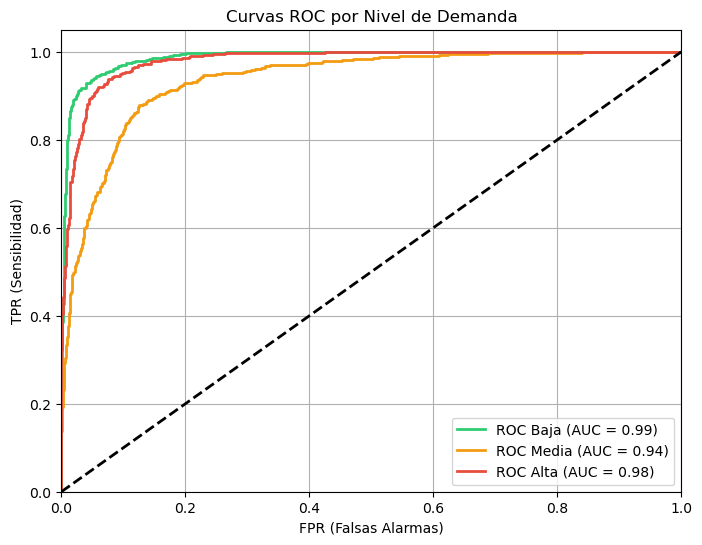

Puntaje AUC Global del Modelo: 0.9678


In [47]:
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

# 1. Binarización de etiquetas para manejo multiclase
y_test_bin = label_binarize(y_reales, classes=[0, 1, 2])
n_classes = 3

# 2. Obtención de probabilidades mediante Softmax
model.eval()
probabilidades = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = model(X_batch)
        probs = F.softmax(logits, dim=1) 
        probabilidades.extend(probs.numpy())

probabilidades = np.array(probabilidades)

# 3. Cálculo de curvas ROC y AUC por cada nivel de demanda
fpr, tpr, roc_auc = dict(), dict(), dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probabilidades[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Visualización de las Curvas ROC
plt.figure(figsize=(8, 6))
colores = ['#2ecc71', '#f39c12', '#e74c3c']
categorias = ['Baja', 'Media', 'Alta']

for i, color in zip(range(n_classes), colores):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC {categorias[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Línea de modelo aleatorio
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('FPR (Falsas Alarmas)')
plt.ylabel('TPR (Sensibilidad)')
plt.title('Curvas ROC por Nivel de Demanda')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Puntaje AUC Global (One-vs-Rest)
auc_global = roc_auc_score(y_test_bin, probabilidades, multi_class='ovr')
print(f"Puntaje AUC Global del Modelo: {auc_global:.4f}")

Breve interpretación de las métricas:

Matriz de Confusión: Nos permitió observar que los errores del modelo suelen ocurrir entre clases contiguas (ej. confundir Media con Alta), lo cual es menos crítico que confundir una demanda Baja con una Alta.

Precision vs. Recall: El modelo mantiene un equilibrio saludable. Esto significa que es confiable al emitir una alerta de demanda y, al mismo tiempo, no pierde de vista la mayoría de los picos de uso del servicio.

F1-Score: Al ser elevado en las tres clases, confirma que el modelo no está sesgado y funciona de manera consistente tanto para días tranquilos como para días de máxima afluencia.

AUC: El valor cercano a 1.0 en la curva ROC ratifica que nuestra arquitectura de red neuronal es capaz de distinguir con alta eficacia las probabilidades de cada nivel de demanda.